In [1]:
import pandas as pd
from tensorflow.python.ops.array_ops import matrix_set_diag

df = pd.read_csv('c:/data/time/pollution.csv', index_col=0)
df

,pollution,dew,temp,pressure,w_dir,w_speed,snow,rain
year_month_day_hour,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0


<Axes: >

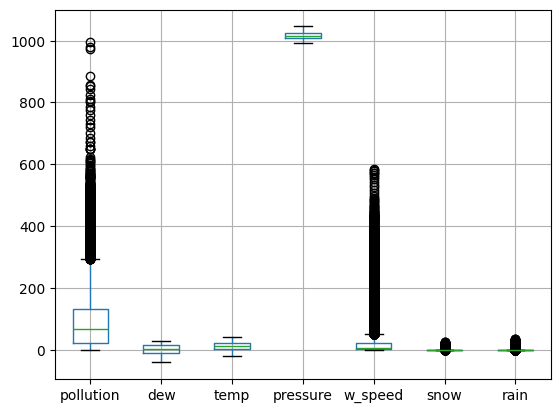

In [2]:
df.boxplot()

In [3]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
values = df.values
encoder = LabelEncoder()
#w_dr 변수 정수인코딩
values[:,4] = encoder.fit_transform(values[:,4])
values = values.astype('float32')
np.unique(values[:,4])

array([0., 1., 2., 3.], dtype=float32)

In [4]:
values

array([[129.  , -16.  ,  -4.  , ...,   1.79,   0.  ,   0.  ],
       [148.  , -15.  ,  -4.  , ...,   2.68,   0.  ,   0.  ],
       [159.  , -11.  ,  -5.  , ...,   3.57,   0.  ,   0.  ],
       ...,
       [ 10.  , -22.  ,  -3.  , ..., 242.7 ,   0.  ,   0.  ],
       [  8.  , -22.  ,  -4.  , ..., 246.72,   0.  ,   0.  ],
       [ 12.  , -21.  ,  -3.  , ..., 249.85,   0.  ,   0.  ]],
      shape=(43800, 8), dtype=float32)

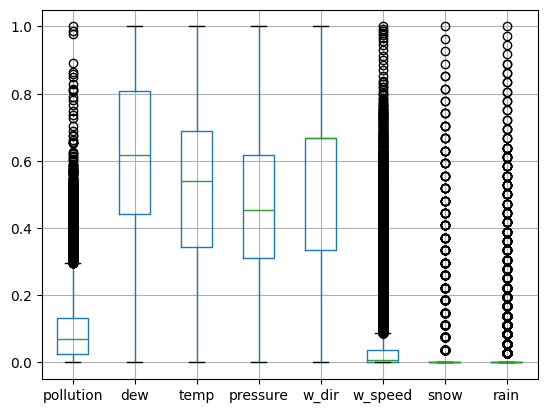

In [5]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()  #모든 변수를 최소값 0 ~ 최대값 1 로 스케일링
scaled = scaler.fit_transform(values)
scaled_df = pd.DataFrame(scaled, columns=df.columns)
scaled_df.boxplot()
plt.show()

In [6]:
len(scaled)

43800

In [9]:
#쉬프트
def shift(train):
    timestep = 4
    X =[]
    y = []
    for i in range(timestep, len(train)):
        X.append(train[i-timestep:i,:]) #pollution~rain
        y.append(train[i,0:1])  #pollution
    return X,y

In [11]:
X, y = shift(scaled)
X = np.array(X)
y = np.array(y)
print(X[:100,:])
print(X.shape)  #3차원
print(y.shape)

[[[0.12977867 0.35294122 0.24590163 ... 0.00229001 0.         0.        ]
  [0.14889336 0.36764708 0.24590163 ... 0.00381099 0.         0.        ]
  [0.15995975 0.4264706  0.22950819 ... 0.00533197 0.         0.        ]
  [0.18209255 0.48529413 0.22950819 ... 0.00839101 0.03703704 0.        ]]

 [[0.14889336 0.36764708 0.24590163 ... 0.00381099 0.         0.        ]
  [0.15995975 0.4264706  0.22950819 ... 0.00533197 0.         0.        ]
  [0.18209255 0.48529413 0.22950819 ... 0.00839101 0.03703704 0.        ]
  [0.13883299 0.48529413 0.22950819 ... 0.00991199 0.07407407 0.        ]]

 [[0.15995975 0.4264706  0.22950819 ... 0.00533197 0.         0.        ]
  [0.18209255 0.48529413 0.22950819 ... 0.00839101 0.03703704 0.        ]
  [0.13883299 0.48529413 0.22950819 ... 0.00991199 0.07407407 0.        ]
  [0.10965794 0.48529413 0.21311474 ... 0.01143297 0.11111111 0.        ]]

 ...

 [[0.07746479 0.22058827 0.0819672  ... 0.006101   0.         0.        ]
  [0.05030181 0.20588237 0

In [12]:
#학습용:검증용 8:2 (4년:1년)
n_train = int(len(X)*.2)+1
X_train, X_test = X[n_train:,], X[:n_train,]
print(X_train.shape, X_test.shape)

(35036, 4, 8) (8760, 4, 8)


In [13]:
y_train, y_test = y[n_train:,], y[:n_train,]
print(y_train.shape, y_test.shape)

(35036, 1) (8760, 1)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
model = Sequential()

#return_sequences = False(기본값, 마지막 스텝만 내보내는 옵션)/True(모든 스텝에 내보내는 옵션->LSTM을 여러층으로 만들 경우 사용)
model.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  #랜덤으로 20% 신호 off <-과적합방지
model.add(LSTM(units = 50, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units = 50))
model.add(Dropout(0.2))
model.add(Dense(units = 1))
model.compile(optimizer='adam', loss='mse')
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 50)          │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 4, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,251 (204.11 KB)

 Trainable params: 52,251 (204.11 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(X_train,y_train, validation_split=0.2, epochs=10, batch_size=32)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 6.1363e-04
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0010 - val_loss: 5.7447e-04
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9.5362e-04 - val_loss: 7.8100e-04
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9.1438e-04 - val_loss: 5.7430e-04
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.9639e-04 - val_loss: 5.8625e-04
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.9155e-04 - val_loss: 6.2902e-04
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.6675e-04 - val_loss: 5.4428e-04
Epoch 9/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.6448e-04 - val_loss: 6.6448e-04
Epoch 10/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.6710e-04 - val_loss: 5.3655e-04


In [16]:
from sklearn.metrics import mean_squared_error
pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
rmse

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


np.float64(0.030650356404948956)

In [17]:
d = scaled[:n_train,:]
y_predicted = np.concatenate((pred, d[:n_train,1:]), axis=1)
y_tested = np.concatenate((y_test, d[:n_train,1:]), axis=1)

In [18]:
y_predicted = scaler.inverse_transform(y_predicted)
y_tested = scaler.inverse_transform(y_tested)
y_predicted = y_predicted[:,0:1]
y_tested = y_tested[:,0:1]

In [19]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_tested, y_predicted)
rmse = np.sqrt(mse)
rmse

np.float64(30.466455242110644)

In [20]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_tested, y_predicted)
print('RMSE', np.sqrt(mse))

RMSE 30.466455242110644


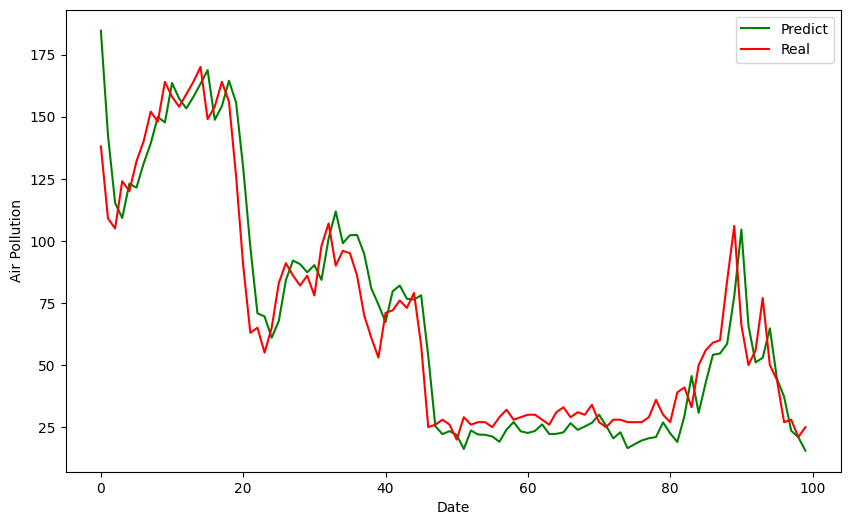

In [21]:
plt.figure(figsize=(10,6))
plt.plot(y_predicted[:100,:],color='g',label='Predict')
plt.plot(y_tested[:100,:],color='r',label='Real')
plt.xlabel('Date')
plt.ylabel('Air Pollution')
plt.legend()
plt.show()